In [1]:
import os
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

In [2]:
def load_maze(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    maze = []
    for line in lines:
        line = line.strip()
        if line:
            maze.append(list(map(int, line.split())))
    return np.array(maze)

In [3]:
DIRECTIONS = [(0,1),(1,0),(0,-1),(-1,0)]

def bfs_solve(maze):
    rows, cols = maze.shape
    start = (1, 0)
    end = (rows-2, cols-1)
    queue = deque([(start, [start])])
    visited = {start}
    while queue:
        (r,c), path = queue.popleft()
        if (r,c) == end:
            return path, len(visited)
        for dr,dc in DIRECTIONS:
            nr,nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr,nc]==0 and (nr,nc) not in visited:
                visited.add((nr,nc))
                queue.append(((nr,nc), path+[(nr,nc)]))
    return None, len(visited)

def count_operations(path):
    if path is None or len(path) < 2:
        return None, len(visited)
    ops = {'go_straight':0, 'turn_left':0, 'turn_right':0, 'u_turn':0}
    ops['go_straight'] += 1
    for i in range(2, len(path)):
        prev_dr = path[i-1][0] - path[i-2][0]
        prev_dc = path[i-1][1] - path[i-2][1]
        curr_dr = path[i][0] - path[i-1][0]
        curr_dc = path[i][1] - path[i-1][1]
        prev_idx = DIRECTIONS.index((prev_dr, prev_dc))
        curr_idx = DIRECTIONS.index((curr_dr, curr_dc))
        diff = (curr_idx - prev_idx) % 4
        if diff == 0: ops['go_straight'] += 1
        elif diff == 1: ops['turn_right'] += 1
        elif diff == 3: ops['turn_left'] += 1
        elif diff == 2: ops['u_turn'] += 1
        return ops

In [4]:
def process_folder(folder, maze_type):
    results = []
    files = sorted([f for f in os.listdir(folder) if f.endswith('.txt')])
    failed = 0
    for fn in tqdm(files, desc=f'Processing {maze_type}'):
        parts = fn.replace('.txt','').split('_')
        dim = int(parts[1].replace('dim',''))
        maze = load_maze(os.path.join(folder, fn))
        path, explored_count = bfs_solve(maze)
        ops = count_operations(path)
        if ops:
            results.append({
                'maze_name': fn.replace('.txt',''), 'maze_type': maze_type,
                'dimension': dim, 'maze_size': f'{dim}x{dim}',
                'grid_size': f'{maze.shape[0]}x{maze.shape[1]}',
                'path_length': len(path),
                'total_operations': explored_count,
                'go_straight': ops['go_straight'],
                'turn_left': ops['turn_left'],
                'turn_right': ops['turn_right'],
                'u_turn': ops['u_turn']
            })
        else:
            failed += 1
            results.append({
                'maze_name': fn.replace('.txt',''), 'maze_type': maze_type,
                'dimension': dim, 'maze_size': f'{dim}x{dim}',
                'grid_size': f'{maze.shape[0]}x{maze.shape[1]}',
                'path_length': 0, 'total_operations': 0,
                'go_straight': 0, 'turn_left': 0, 'turn_right': 0, 'u_turn': 0
            })
    print(f'Da xu ly {len(files)} maze ({maze_type})')
    if failed > 0: print(f'{failed} maze khong tim duoc duong')
    return results

perfect_results = process_folder('perfect_maze', 'perfect')
df_perfect = pd.DataFrame(perfect_results)
print(df_perfect[['total_operations','go_straight','turn_left','turn_right','u_turn']].describe().round(2))

Processing perfect:   0%|          | 0/1500 [00:00<?, ?it/s]

Processing perfect: 100%|██████████| 1500/1500 [03:12<00:00,  7.78it/s]

Da xu ly 1500 maze (perfect)
       total_operations  go_straight  turn_left  turn_right  u_turn
count           1500.00      1500.00     1500.0     1500.00  1500.0
mean            9061.53         1.47        0.0        0.53     0.0
std             8733.77         0.50        0.0        0.50     0.0
min               66.00         1.00        0.0        0.00     0.0
25%             1950.25         1.00        0.0        0.00     0.0
50%             6495.00         1.00        0.0        1.00     0.0
75%            13852.75         2.00        0.0        1.00     0.0
max            43843.00         2.00        0.0        1.00     0.0


In [5]:
imperfect_results = process_folder('imperfect_maze', 'imperfect')
df_imperfect = pd.DataFrame(imperfect_results)
print(df_imperfect[['total_operations','go_straight','turn_left','turn_right','u_turn']].describe().round(2))

Processing imperfect: 100%|██████████| 1500/1500 [00:58<00:00, 25.75it/s]

Da xu ly 1500 maze (imperfect)
       total_operations  go_straight  turn_left  turn_right  u_turn
count           1500.00      1500.00     1500.0     1500.00  1500.0
mean           17621.14         1.52        0.0        0.48     0.0
std            14756.90         0.50        0.0        0.50     0.0
min              114.00         1.00        0.0        0.00     0.0
25%             4312.50         1.00        0.0        0.00     0.0
50%            13854.00         2.00        0.0        0.00     0.0
75%            29160.50         2.00        0.0        1.00     0.0
max            51145.00         2.00        0.0        1.00     0.0


In [6]:
df_all = pd.concat([df_perfect, df_imperfect], ignore_index=True)
df_valid = df_all[df_all['total_operations'] > 0]

print('TONG HOP KET QUA 3000 MAZES')
print(f'Tong maze: {len(df_all)}')
print(f'  Perfect:   {len(df_perfect)}')
print(f'  Imperfect: {len(df_imperfect)}')
print(f'  Co duong di: {len(df_valid)}')
print()
avg_total = df_valid['total_operations'].mean()
print(f'TRUNG BINH TONG THAO TAC: {avg_total:.2f}')
print(f'  Di thang:  {df_valid["go_straight"].mean():.2f}')
print(f'  Re trai:   {df_valid["turn_left"].mean():.2f}')
print(f'  Re phai:   {df_valid["turn_right"].mean():.2f}')
print(f'  Quay dau:  {df_valid["u_turn"].mean():.2f}')
print()
print(f'TB perfect:   {df_valid[df_valid["maze_type"]=="perfect"]["total_operations"].mean():.2f}')
print(f'TB imperfect: {df_valid[df_valid["maze_type"]=="imperfect"]["total_operations"].mean():.2f}')
print(f'Min: {df_valid["total_operations"].min()}, Max: {df_valid["total_operations"].max()}')
print()
print(df_valid[['total_operations','go_straight','turn_left','turn_right','u_turn','path_length']].describe().round(2))

TONG HOP KET QUA 3000 MAZES
Tong maze: 3000
  Perfect:   1500
  Imperfect: 1500
  Co duong di: 3000

TRUNG BINH TONG THAO TAC: 13341.34
  Di thang:  1.50
  Re trai:   0.00
  Re phai:   0.50
  Quay dau:  0.00

TB perfect:   9061.53
TB imperfect: 17621.14
Min: 66, Max: 51145

       total_operations  go_straight  turn_left  turn_right  u_turn  \
count           3000.00       3000.0     3000.0      3000.0  3000.0   
mean           13341.34          1.5        0.0         0.5     0.0   
std            12856.76          0.5        0.0         0.5     0.0   
min               66.00          1.0        0.0         0.0     0.0   
25%             2860.75          1.0        0.0         0.0     0.0   
50%             8948.50          1.0        0.0         1.0     0.0   
75%            20271.50          2.0        0.0         1.0     0.0   
max            51145.00          2.0        0.0         1.0     0.0   

       path_length  
count      3000.00  
mean       2149.43  
std        2948.42  
m

In [7]:
df_sorted = df_all.sort_values(['maze_type','maze_name']).reset_index(drop=True)
df_export = df_sorted.rename(columns={
    'maze_name':'Ten Maze','maze_type':'Loai Maze','dimension':'Kich thuoc (dim)',
    'maze_size':'Kich thuoc Maze','grid_size':'Kich thuoc Grid',
    'path_length':'Do dai duong di','total_operations':'Tong thao tac',
    'go_straight':'Di thang','turn_left':'Re trai','turn_right':'Re phai','u_turn':'Quay dau'
})

excel_path = 'maze_operations_result.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='All Mazes', index=False)
    df_export[df_export['Loai Maze']=='perfect'].to_excel(writer, sheet_name='Perfect Mazes', index=False)
    df_export[df_export['Loai Maze']=='imperfect'].to_excel(writer, sheet_name='Imperfect Mazes', index=False)
    avg_p = df_valid[df_valid['maze_type']=='perfect']['total_operations'].mean()
    avg_i = df_valid[df_valid['maze_type']=='imperfect']['total_operations'].mean()
    stats = pd.DataFrame({
        'Thong ke': ['Tong so maze','Perfect mazes','Imperfect mazes',
                     'TB thao tac (tat ca)','TB thao tac (perfect)','TB thao tac (imperfect)',
                     'TB di thang','TB re trai','TB re phai','TB quay dau',
                     'Min thao tac','Max thao tac'],
        'Gia tri': [len(df_all), len(df_perfect), len(df_imperfect),
                    round(avg_total,2), round(avg_p,2), round(avg_i,2),
                    round(df_valid['go_straight'].mean(),2),
                    round(df_valid['turn_left'].mean(),2),
                    round(df_valid['turn_right'].mean(),2),
                    round(df_valid['u_turn'].mean(),2),
                    df_valid['total_operations'].min(),
                    df_valid['total_operations'].max()]
    })
    stats.to_excel(writer, sheet_name='Summary', index=False)

print(f'Da xuat: {excel_path}')
print(f'Gom 4 sheets, tong {len(df_all)} dong')

Da xuat: maze_operations_result.xlsx
Gom 4 sheets, tong 3000 dong


In [8]:
print('Mau 10 dong dau:')
df_export.head(10)

Mau 10 dong dau:


,Ten Maze,Loai Maze,Kich thuoc (dim),Kich thuoc Maze,Kich thuoc Grid,Do dai duong di,Tong thao tac,Di thang,Re trai,Re phai,Quay dau
0,maze0_dim52,imperfect,52,52x52,105x105,229,6153,2,0,0,0
1,maze1000_dim83,imperfect,83,83x83,167x167,357,15368,2,0,0,0
2,maze1001_dim28,imperfect,28,28x28,57x57,171,1686,1,0,1,0
3,maze1002_dim141,imperfect,141,141x141,283x283,813,41637,1,0,1,0
4,maze1003_dim57,imperfect,57,57x57,115x115,321,6786,2,0,0,0
5,maze1004_dim143,imperfect,143,143x143,287x287,601,45379,2,0,0,0
6,maze1005_dim43,imperfect,43,43x43,87x87,201,4047,2,0,0,0
7,maze1006_dim106,imperfect,106,106x106,213x213,615,23543,2,0,0,0
8,maze1007_dim116,imperfect,116,116x116,233x233,493,30293,1,0,1,0
9,maze1008_dim20,imperfect,20,20x20,41x41,89,876,2,0,0,0


Maze khó nhất: maze1236_dim150 (imperfect)
Số ô phải duyệt: 51145


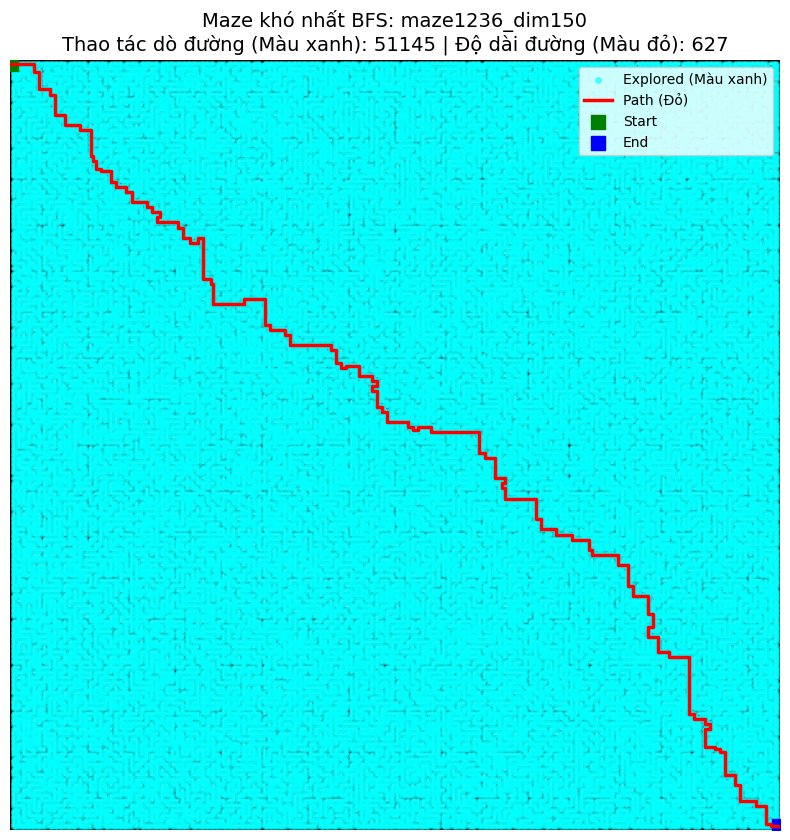

In [9]:
# TÌM VÀ TRỰC QUAN HÓA MAZE KHÓ NHẤT (Nhiều thao tác dò đường nhất)
hardest_maze = df_valid.loc[df_valid['total_operations'].idxmax()]
maze_folder = 'perfect_maze' if hardest_maze['maze_type'] == 'perfect' else 'imperfect_maze'
hardest_maze_path = os.path.join(maze_folder, hardest_maze['maze_name'] + '.txt')

print(f"Maze khó nhất: {hardest_maze['maze_name']} ({hardest_maze['maze_type']})")
print(f"Số ô phải duyệt: {hardest_maze['total_operations']}")

# Load maze
maze_hard = load_maze(hardest_maze_path)

# Hàm BFS dành riêng cho trực quan hóa (lưu lại danh sách tọa độ thay vì chỉ số lượng)
def bfs_demo_viz(maze):
    rows,cols = maze.shape
    start,end = (1,0),(rows-2,cols-1)
    q = deque([(start, [start])])
    v = set([start])
    visited_order = []
    
    while q:
        (r,c), p = q.popleft()
        visited_order.append((r,c))
        if (r,c)==end: 
            return p, visited_order
        for dr,dc in DIRECTIONS:
            nr,nc=r+dr,c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr,nc]==0 and (nr,nc) not in v:
                v.add((nr,nc))
                q.append(((nr,nc), p+[(nr,nc)]))
    return None, visited_order

import matplotlib.pyplot as plt

def visualize_maze(maze, path, visited, title="Maze Solution"):
    plt.figure(figsize=(10, 10))
    cmap = plt.cm.binary
    plt.imshow(maze, cmap=cmap)
    
    if visited:
        vis_arr = np.array(visited)
        plt.scatter(vis_arr[:, 1], vis_arr[:, 0], c='cyan', s=15, alpha=0.6, label='Explored (Màu xanh)')
        
    if path:
        path_arr = np.array(path)
        plt.plot(path_arr[:, 1], path_arr[:, 0], c='red', linewidth=2.5, label='Path (Đỏ)')
        
    rows, cols = maze.shape
    start, end = (1, 0), (rows-2, cols-1)
    plt.scatter(start[1], start[0], c='green', s=100, marker='s', label='Start')
    plt.scatter(end[1], end[0], c='blue', s=100, marker='s', label='End')
    
    plt.title(f"{title}\nThao tác dò đường (Màu xanh): {len(visited)} | Độ dài đường (Màu đỏ): {len(path)}", fontsize=14)
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()

path_hard, vis_hard = bfs_demo_viz(maze_hard)
visualize_maze(maze_hard, path_hard, vis_hard, f"Maze khó nhất BFS: {hardest_maze['maze_name']}")